# Case Study Insights: Gradient Boosting

**Docker image**: `ml4t`

**Purpose**: assemble the cross-case-study view of LightGBM and contrast it
with the linear baseline (Ch11) and the tabular deep-learning variant (TabM).
Per-case-study deep dives live in `case_studies/{cs}/13_model_analysis.py`;
this notebook is the comparative view across all nine case studies.

**Learning objectives**

- For each case study, read the highest-IC GBM configuration's average daily
  Spearman IC with HAC interval on the primary label
- Compare GBM design choices - loss function, tree depth, optimal iteration
  count - and locate the operating regime that achieves the highest IC
- Inspect per-fold IC distributions and the validation to holdout decay where
  the holdout retrain has been run
- Compare full-coverage GBM and linear daily-IC point estimates without
  treating fold summaries as an uncertainty estimator, faceted across labels
- Extend the comparison across labels (horizon view) and across the
  classification ↔ regression metric symmetry
- Inspect feature-importance rank shift versus the linear baseline, per-fold rank
  stability, and the TabM-vs-GBM-vs-linear three-way picture

**Book reference**: Section 12.6 - Case study insights.

**Prerequisites**: each case study's `07_gbm.py` pipeline has populated
`run_log/registry.db` for the GBM family. Where present, `tabular_dl.py`
adds TabM rows. Teaching notebooks NB01-NB11 cover the underlying techniques.

In [1]:
"""Case Study Insights: Gradient Boosting cross-case-study registry aggregation.

Every comparison below ranks only configurations that covered the same folds and the
same number of days.
"""

import sqlite3
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# ml4t.diagnostic dlopens cudart; load torch first so its bundled CUDA
# runtime wins. Same precedence pattern as case_studies/utils/model_analysis.py.
import torch  # noqa: F401
from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from scipy.stats import rankdata
from sklearn.exceptions import InconsistentVersionWarning
from sklearn.metrics import roc_auc_score

from case_studies.utils.analytics import (
    CASE_STUDY_IDS,
    PRIMARY_LABELS,
    SHORT_NAMES,
)
from case_studies.utils.insight_chapter import (
    SYMMETRY_TABLE_SCHEMA,
    collect_fold_ic_per_cs,
    collect_gbm_checkpoint_trajectories,
    collect_grid_per_cs,
    collect_multi_label_per_cs,
    collect_rank1_per_cs,
    discover_symmetry_pairs,
    load_gbm_feature_importance,
    parse_gbm_config,
    plot_cross_cs_forest,
)
from case_studies.utils.model_analysis import (
    load_metrics_from_registry,
    load_predictions,
)
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, ml4t_diverging, ml4t_palette, show_with_alt

# LightGBM records synthetic feature names when fitted on an array with an eval_set,
# and sklearn then warns at every predict on an array that has none to compare. One
# message, not the category: the fit and the predictions are unaffected.
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names",
    category=UserWarning,
    module="sklearn.utils.validation",
)

In [2]:
FAMILY = "gbm"
BASELINE_FAMILY = "linear"
SEED = 42

In [3]:
set_global_seeds(SEED)

## 1. Scope and Coverage

The GBM grid spans four tree-depth profiles
(7 / 15 / 31 / 63 leaves) × 3 regression loss functions (MSE / MAE /
Huber), evaluated at 10 boosting checkpoints per configuration. Direction
labels add a binary-logistic variant. The headline metric is average daily
cross-sectional Spearman IC with a HAC confidence interval on the primary label
(`prediction_metrics.ic_mean_daily`, `ic_ci_lo`, `ic_ci_hi`, `ic_t_hac`).
The linear family (Ch11) and TabM (`tabular_dl`) are loaded as baselines.

In [4]:
coverage_rows = []
for cs in CASE_STUDY_IDS:
    primary = PRIMARY_LABELS[cs]
    gbm = load_metrics_from_registry(cs, families=[FAMILY])
    tabm = load_metrics_from_registry(cs, families=["tabular_dl"])
    lin = load_metrics_from_registry(cs, families=[BASELINE_FAMILY])
    coverage_rows.append(
        {
            "case_study": SHORT_NAMES[cs],
            "primary_label": primary,
            "gbm_labels": gbm["label"].n_unique() if not gbm.is_empty() else 0,
            "gbm_configs_primary": (
                gbm.filter(pl.col("label") == primary)["config_name"].n_unique()
                if not gbm.is_empty()
                else 0
            ),
            "tabm_configs": tabm["config_name"].n_unique() if not tabm.is_empty() else 0,
            "linear_present": not lin.is_empty(),
        }
    )

coverage_df = pl.DataFrame(coverage_rows)
print("GBM / TabM / Linear coverage per case study (primary label and labels trained):")
coverage_df

GBM / TabM / Linear coverage per case study (primary label and labels trained):


case_study,primary_label,gbm_labels,gbm_configs_primary,tabm_configs,linear_present
str,str,i64,i64,i64,bool
"""ETFs""","""fwd_ret_21d""",2,15,3,true
"""Crypto""","""fwd_ret_8h""",4,15,3,true
"""NQ100""","""fwd_ret_15m""",4,15,0,true
"""SP500 Eq+Opt""","""fwd_ret_5d""",5,15,3,true
"""US Firms""","""fwd_ret_1m""",3,15,3,true
"""FX""","""fwd_ret_1d""",3,15,3,true
"""CME Futures""","""fwd_ret_5d""",2,15,3,true
"""SP500 Options""","""ret_to_expiry""",1,15,3,true
"""US Equities""","""fwd_ret_1d""",3,15,3,true


## 2. Cross-CS Forest of Highest-IC GBM Configurations

For each case study, the GBM configuration with the highest average daily IC
on the primary label is plotted with its HAC interval. Filled markers
indicate $|t_{HAC}| > 2$ (CI excludes zero); open markers indicate the CI
overlaps zero.

In [5]:
gbm_rank1 = collect_rank1_per_cs(
    CASE_STUDY_IDS,
    family=FAMILY,
)
print(
    "Highest-IC GBM configuration per case study (primary label, average daily IC ± HAC 95 % CI):"
)
gbm_rank1.select(
    "short_name",
    "label",
    "config_name",
    pl.col("checkpoint_value").cast(pl.Int64).alias("trees"),
    pl.col("ic_mean_daily").round(4).alias("ic"),
    pl.col("ic_ci_lo").round(4).alias("ci_lo"),
    pl.col("ic_ci_hi").round(4).alias("ci_hi"),
    pl.col("ic_t_hac").round(2).alias("t_hac"),
    pl.col("ic_n_days").cast(pl.Int64).alias("n_days"),
)

Highest-IC GBM configuration per case study (primary label, average daily IC ± HAC 95 % CI):


short_name,label,config_name,trees,ic,ci_lo,ci_hi,t_hac,n_days
str,str,str,i64,f64,f64,f64,f64,i64
"""ETFs""","""fwd_ret_21d""","""leaves_7_huber""",50,0.0547,0.0137,0.0956,2.61,1995
"""Crypto""","""fwd_ret_8h""","""leaves_63_huber""",150,0.0344,0.0221,0.0467,5.48,2189
"""NQ100""","""fwd_ret_15m""","""leaves_63_huber""",500,0.0091,0.0062,0.012,6.13,78812
"""SP500 Eq+Opt""","""fwd_ret_5d""","""leaves_7_mse""",50,0.0039,-0.018,0.0258,0.35,497
"""US Firms""","""fwd_ret_1m""","""leaves_7_mae""",350,0.0836,0.0602,0.107,7.08,110
"""FX""","""fwd_ret_1d""","""default_mae""",50,0.0035,-0.0106,0.0176,0.49,2063
"""CME Futures""","""fwd_ret_5d""","""default_mae""",200,0.0214,-0.0075,0.0504,1.45,1285
"""SP500 Options""","""ret_to_expiry""","""leaves_7_mae""",150,0.0078,-0.013,0.0286,0.74,478
"""US Equities""","""fwd_ret_1d""","""leaves_63_mae""",500,0.0311,0.0271,0.035,15.53,4031


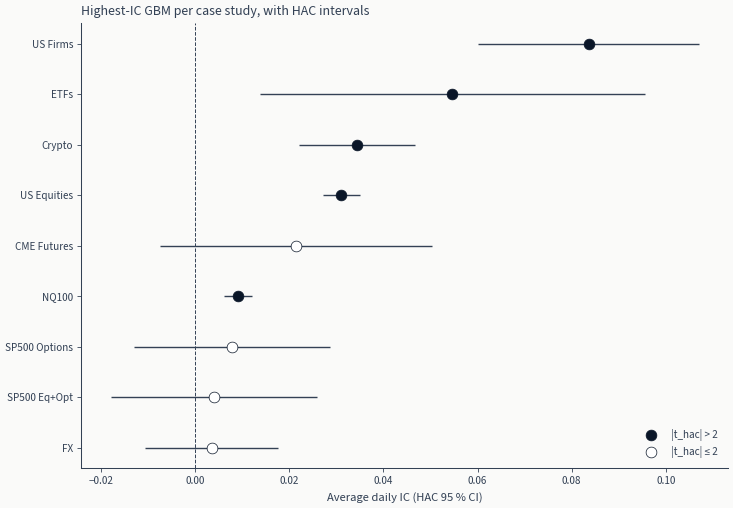

In [6]:
fig, forest_ax = plot_cross_cs_forest(
    gbm_rank1,
    family=FAMILY,
    title="Highest-IC GBM per case study, with HAC intervals",
)
forest_ax.set_xlabel("Average daily IC (HAC 95 % CI)")
show_with_alt(
    fig,
    "Forest plot of average daily IC with a HAC interval, one row per case study on its "
    "primary label, against a vertical line at zero. A filled marker is an interval that "
    "excludes zero and an open one an interval that does not.",
)

The next cell derives the cross-case conclusion from the selected rows, naming
no case study or value that it has not just computed.

In [7]:
clear_zero = gbm_rank1.filter((pl.col("ic_ci_lo") > 0) | (pl.col("ic_ci_hi") < 0))[
    "short_name"
].to_list()
overlap_zero = gbm_rank1.filter((pl.col("ic_ci_lo") <= 0) & (pl.col("ic_ci_hi") >= 0))[
    "short_name"
].to_list()
display(
    Markdown(
        "**Computed reading.** "
        f"The GBM HAC interval excludes zero for {len(clear_zero)} of "
        f"{gbm_rank1.height} case studies ({', '.join(clear_zero) or 'none'}). "
        f"It overlaps zero for {', '.join(overlap_zero) or 'none'}."
    )
)

**Computed reading.** The GBM HAC interval excludes zero for 5 of 9 case studies (ETFs, Crypto, NQ100, US Firms, US Equities). It overlaps zero for SP500 Eq+Opt, FX, CME Futures, SP500 Options.

## 3. Within-Family Comparison

How much does each design knob change the IC at the primary label? Three
subsections trace the structured grid: loss function (3a), tree depth (3b),
and checkpoint dynamics (3c). Each is presented with HAC intervals so the
resolution between operating points stays explicit.

In [8]:
grid_primary = collect_grid_per_cs(
    CASE_STUDY_IDS,
    FAMILY,
    config_parser=parse_gbm_config,
)
grid_regression = grid_primary.filter(pl.col("objective_kind") == "regression")
print(
    f"Per-(CS, config) GBM grid: {grid_primary.height} rows total, "
    f"{grid_regression.height} regression rows."
)

Per-(CS, config) GBM grid: 135 rows total, 135 regression rows.


### 3a. Loss function (MSE / MAE / Huber)

For each case study, the highest-IC configuration is selected within each
regression loss family, then the three (case study, loss) IC values are plotted
side by side with HAC interval bars.

In [9]:
loss_best = (
    grid_regression.sort("ic_mean_daily", descending=True, nulls_last=True)
    .unique(subset=["case_study", "loss"], keep="first")
    .filter(pl.col("loss").is_in(["mse", "mae", "huber"]))
)

In [10]:
losses_present = ["mse", "mae", "huber"]
loss_colors = {
    "mse": COLORS["neutral"],
    "mae": COLORS["blue"],
    "huber": COLORS["copper"],
}
cs_order = sorted(loss_best["short_name"].unique().to_list())

The helper adds bars and intervals without rendering an unfinished figure
between notebook cells.

In [11]:
def add_loss_bars(ax: plt.Axes, x: np.ndarray, width: float) -> None:
    for i, loss in enumerate(losses_present):
        sub = loss_best.filter(pl.col("loss") == loss)
        ic, err_lo, err_hi = [], [], []
        for cs in cs_order:
            row = sub.filter(pl.col("short_name") == cs)
            if row.height == 0:
                ic.append(np.nan)
                err_lo.append(0.0)
                err_hi.append(0.0)
            else:
                r = row.row(0, named=True)
                ic.append(r["ic_mean_daily"])
                err_lo.append(r["ic_mean_daily"] - r["ic_ci_lo"])
                err_hi.append(r["ic_ci_hi"] - r["ic_mean_daily"])
        ax.bar(
            x + (i - 1) * width,
            np.array(ic, dtype=float),
            width=width,
            yerr=np.vstack([err_lo, err_hi]),
            capsize=2,
            color=loss_colors[loss],
            alpha=0.9,
            label=loss.upper(),
        )

Shared labels and a zero line make the grouped confidence intervals comparable.

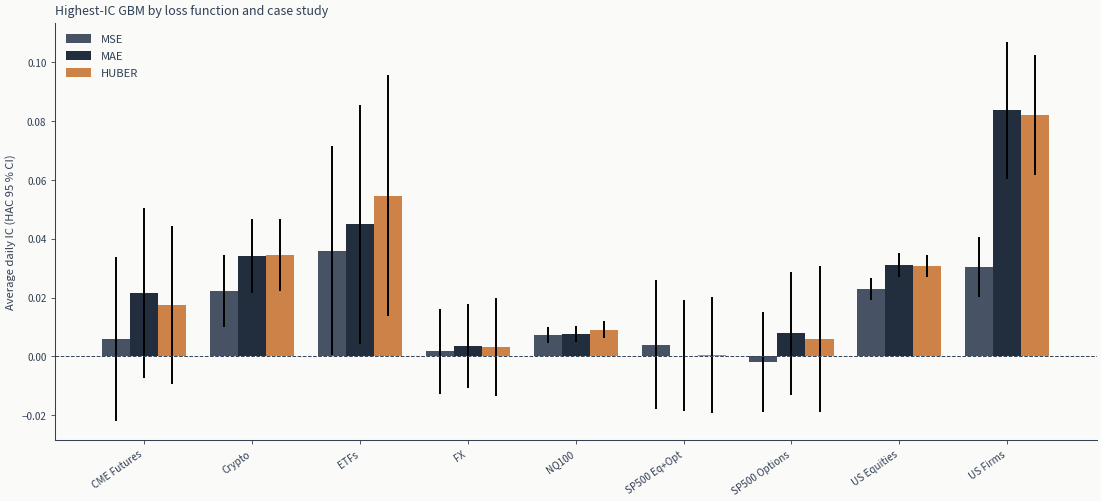

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(cs_order))
width = 0.26
add_loss_bars(ax, x, width)
ax.set_xticks(x)
ax.set_xticklabels(cs_order, rotation=35, ha="right")
ax.axhline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
ax.set_ylabel("Average daily IC (HAC 95 % CI)")
ax.set_title("Highest-IC GBM by loss function and case study")
ax.legend(frameon=False, fontsize=9, loc="best")
show_with_alt(
    fig,
    "Grouped bars of average daily IC, one group per case study and one bar per loss "
    "function, against a line at zero.",
)

In [13]:
# Aggregate: which loss achieves the highest of the three on each CS?
loss_top_per_cs = (
    loss_best.sort("ic_mean_daily", descending=True, nulls_last=True)
    .group_by("short_name", maintain_order=True)
    .first()
    .group_by("loss", maintain_order=True)
    .len()
    .rename({"len": "n_cs_with_highest_ic"})
    .sort(["n_cs_with_highest_ic", "loss"], descending=[True, False])
)
print(
    "Loss function achieving the highest IC per case study (count across regression-primary CSs):"
)
loss_top_per_cs

Loss function achieving the highest IC per case study (count across regression-primary CSs):


loss,n_cs_with_highest_ic
str,u32
"""mae""",5
"""huber""",3
"""mse""",1


In [14]:
loss_count_text = ", ".join(
    f"{row['loss'].upper()}: {row['n_cs_with_highest_ic']}"
    for row in loss_top_per_cs.iter_rows(named=True)
)
display(
    Markdown(
        f"**Computed loss comparison.** Highest-IC loss counts are {loss_count_text}. "
        "The plotted HAC intervals show whether within-panel loss differences are resolved."
    )
)

**Computed loss comparison.** Highest-IC loss counts are MAE: 5, HUBER: 3, MSE: 1. The plotted HAC intervals show whether within-panel loss differences are resolved.

### 3b. Tree depth heatmap

Within each case study, the highest IC achieved by each leaf profile -
7 / 15 / 31 / 63 leaves - is shown as a heatmap cell. Panels with a
clean diagonal favor a specific depth; panels that are nearly flat across
leaves indicate the depth knob has no resolution at this signal-to-noise
ratio.

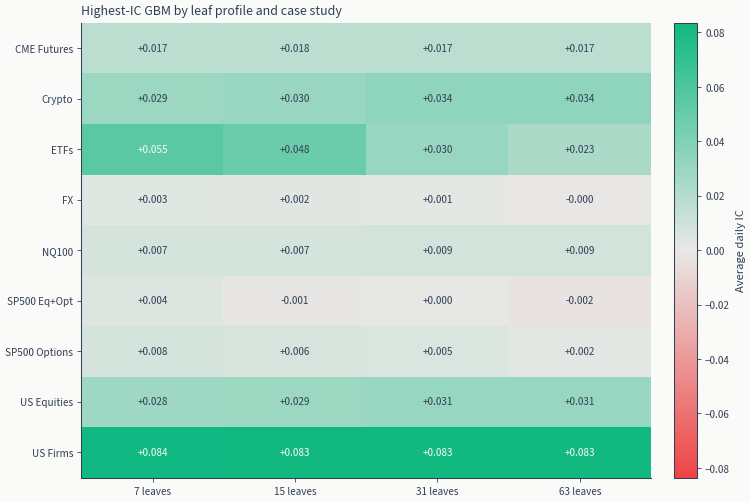

In [15]:
depth_pivot = (
    grid_regression.filter(pl.col("leaves").is_not_null())
    .group_by(["short_name", "leaves"], maintain_order=True)
    .agg(pl.col("ic_mean_daily").max().alias("ic"))
    .sort(["short_name", "leaves"])
)
ic_matrix = depth_pivot.pivot(index="short_name", on="leaves", values="ic").sort("short_name")
leaf_cols = sorted(
    [c for c in ic_matrix.columns if c != "short_name"],
    key=lambda s: int(s),
)
matrix_values = ic_matrix.select(leaf_cols).to_numpy()
cs_labels = ic_matrix["short_name"].to_list()

fig, ax = plt.subplots(figsize=(7.5, 5))
vmax = float(np.nanmax(np.abs(matrix_values))) if np.isfinite(matrix_values).any() else 0.05
diverging_cmap = LinearSegmentedColormap.from_list("ml4t_diverging", ml4t_diverging())
im = ax.imshow(matrix_values, cmap=diverging_cmap, vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(np.arange(len(leaf_cols)))
ax.set_xticklabels([f"{c} leaves" for c in leaf_cols])
ax.set_yticks(np.arange(len(cs_labels)))
ax.set_yticklabels(cs_labels)
for i in range(len(cs_labels)):
    for j in range(len(leaf_cols)):
        v = matrix_values[i, j]
        if np.isfinite(v):
            ax.text(
                j,
                i,
                f"{v:+.3f}",
                ha="center",
                va="center",
                fontsize=8,
                color=COLORS["silver"] if abs(v) > 0.6 * vmax else COLORS["neutral"],
            )
ax.set_title("Highest-IC GBM by leaf profile and case study")
fig.colorbar(im, ax=ax, fraction=0.045, pad=0.04, label="Average daily IC")
show_with_alt(
    fig,
    "Heatmap of average daily IC with one row per case study and one column per leaf "
    "count, each cell shaded by its value against the colour bar.",
)

In [16]:
depth_spread = (
    depth_pivot.group_by("short_name", maintain_order=True)
    .agg(
        min_ic=pl.col("ic").min(),
        max_ic=pl.col("ic").max(),
        n_leaf_profiles=pl.col("leaves").n_unique(),
    )
    .with_columns(spread=pl.col("max_ic") - pl.col("min_ic"))
    .sort("spread", descending=True)
)
widest_depth = depth_spread.row(0, named=True)
display(
    Markdown(
        f"**Computed depth comparison.** {widest_depth['short_name']} has the widest "
        f"leaf-profile range in this snapshot ({widest_depth['spread']:+.4f} IC across "
        f"{widest_depth['n_leaf_profiles']} profiles). Read each range against that panel's "
        "HAC interval rather than treating the largest point estimate as a resolved difference."
    )
)

**Computed depth comparison.** ETFs has the widest leaf-profile range in this snapshot (+0.0313 IC across 4 profiles). Read each range against that panel's HAC interval rather than treating the largest point estimate as a resolved difference.

### 3c. Checkpoint dynamics

Where in the boosting trajectory does the highest-IC checkpoint sit? For
each case study we plot the highest-validation-IC GBM configuration's mean
cross-sectional IC against the boosting checkpoint (number of trees,
50–500). The trajectory is read from `learning_curves.parquet` written by
the boosting runner during training; the final early-stopped checkpoint is
the IC that propagates to the selected row in `prediction_metrics`.

In [17]:
ckpt_df = collect_gbm_checkpoint_trajectories(gbm_rank1)
if ckpt_df.is_empty() or "short_name" not in ckpt_df.columns:
    msg = (
        "collect_gbm_checkpoint_trajectories returned no rows - "
        "learning_curves.parquet is missing for every case study. "
        "Re-run the GBM boosting sweep before this notebook."
    )
    raise RuntimeError(msg)
print(
    f"Per-checkpoint IC for {ckpt_df['short_name'].n_unique()} case studies "
    f"({ckpt_df.height} (CS, iteration) rows)."
)

Per-checkpoint IC for 9 case studies (90 (CS, iteration) rows).


In [18]:
# Ordered by the iteration of each case study's peak IC, ties by peak magnitude.
peak_table = (
    ckpt_df.group_by("short_name", maintain_order=True)
    .agg(
        pl.col("iteration")
        .filter(pl.col("ic_mean") == pl.col("ic_mean").max())
        .first()
        .alias("argmax_iter"),
        pl.col("ic_mean").max().alias("max_ic"),
    )
    .sort(["argmax_iter", "max_ic"], descending=[False, True])
)
cs_order = peak_table["short_name"].to_list()

Small multiples keep each trajectory on its own axis while sharing the tree budget.

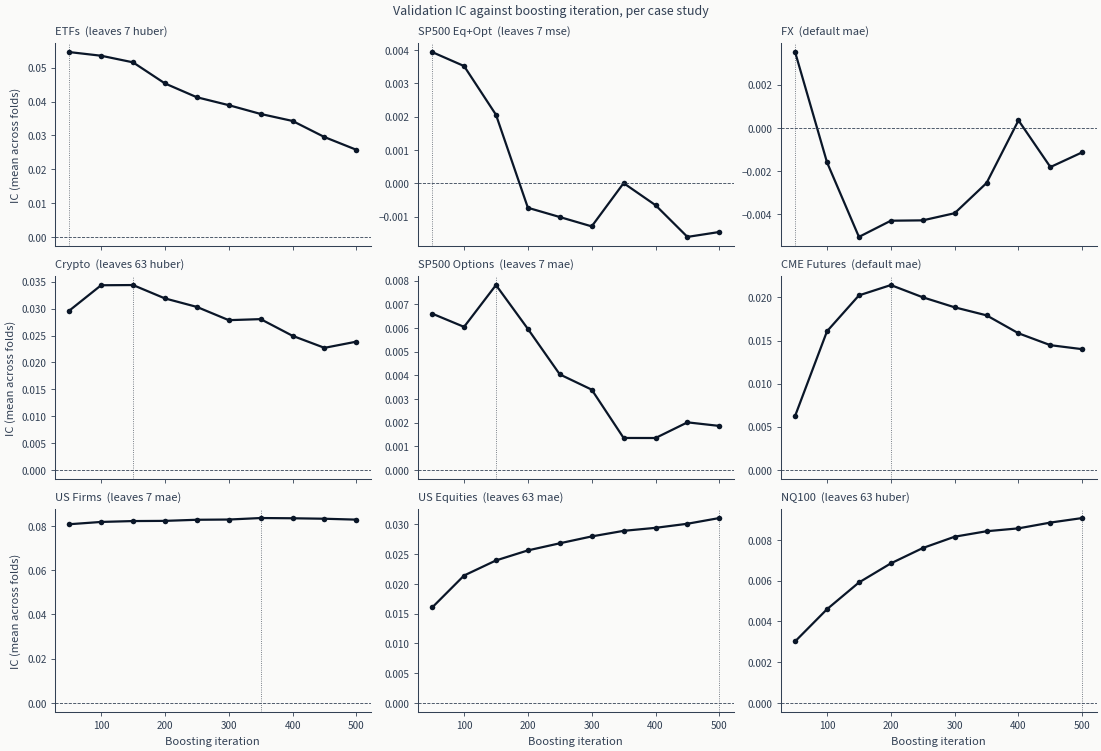

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(11, 7.5), sharex=True)
for i, cs in enumerate(cs_order):
    ax = axes.flat[i]
    sub = ckpt_df.filter(pl.col("short_name") == cs).sort("iteration")
    cfg = sub["config_name"].first()
    x = sub["iteration"].to_numpy()
    ic = sub["ic_mean"].to_numpy()
    color = COLORS["blue"]
    argmax = int(x[ic.argmax()])
    ax.plot(x, ic, "o-", color=color, linewidth=1.6, markersize=4)
    ax.axvline(argmax, color=color, linewidth=0.6, linestyle=":", alpha=0.7)
    ax.axhline(0, color=COLORS["neutral"], linewidth=0.6, linestyle="--")
    ax.set_title(f"{cs}  ({cfg.replace('_', ' ')})", fontsize=9)
    if i % 3 == 0:
        ax.set_ylabel("IC (mean across folds)")
    if i // 3 == 2:
        ax.set_xlabel("Boosting iteration")
min_peak = int(peak_table["argmax_iter"].min())
max_peak = int(peak_table["argmax_iter"].max())
fig.suptitle("Validation IC against boosting iteration, per case study", fontsize=10)
show_with_alt(
    fig,
    "One small panel per case study, each showing validation IC against boosting "
    "iteration for that case study's selected configuration, with the peak marked.",
)

In [20]:
peak_table

short_name,argmax_iter,max_ic
str,i64,f64
"""ETFs""",50,0.054657
"""SP500 Eq+Opt""",50,0.003935
"""FX""",50,0.003515
"""Crypto""",150,0.034398
"""SP500 Options""",150,0.007815
"""CME Futures""",200,0.021442
"""US Firms""",350,0.08359
"""US Equities""",500,0.031068
"""NQ100""",500,0.009086


In [21]:
early_peaks = peak_table.filter(pl.col("argmax_iter") <= 150)["short_name"].to_list()
budget_peaks = peak_table.filter(pl.col("argmax_iter") == max_peak)["short_name"].to_list()
display(
    Markdown(
        f"**Computed checkpoint reading.** {len(early_peaks)} of {peak_table.height} panels "
        f"peak by 150 trees ({', '.join(early_peaks) or 'none'}). "
        f"{len(budget_peaks)} peak at the observed {max_peak}-tree boundary "
        f"({', '.join(budget_peaks) or 'none'})."
    )
)

**Computed checkpoint reading.** 5 of 9 panels peak by 150 trees (ETFs, SP500 Eq+Opt, FX, Crypto, SP500 Options). 2 peak at the observed 500-tree boundary (US Equities, NQ100).

## 4. Stability and Uncertainty

Average daily IC with HAC CI is the headline metric. Per-fold IC is the
stability diagnostic, and the validation→holdout decay is the
generalization diagnostic.

### 4a. Per-fold IC distribution

For each case study's highest-IC GBM configuration, the per-fold IC
distribution is shown as a box-plus-scatter. The reference comparison is
Ch11 §4 - the linear panels frame the GBM panels' fold-stability picture.

In [22]:
gbm_fold = collect_fold_ic_per_cs(gbm_rank1)
gbm_fold_summary = (
    gbm_fold.group_by(["case_study", "short_name"], maintain_order=True)
    .agg(
        n_folds=pl.col("ic").count(),
        median=pl.col("ic").median(),
        std=pl.col("ic").std(),
        pct_positive=(pl.col("ic") > 0).mean(),
    )
    .sort("median", descending=True)
)
print("Per-fold IC summary for the highest-IC GBM configuration (primary label):")
gbm_fold_summary

Per-fold IC summary for the highest-IC GBM configuration (primary label):


case_study,short_name,n_folds,median,std,pct_positive
str,str,u32,f64,f64,f64
"""us_firm_characteristics""","""US Firms""",10,0.081315,0.036869,1.0
"""etfs""","""ETFs""",8,0.066248,0.05358,0.875
"""crypto_perps_funding""","""Crypto""",2,0.03439,0.023091,1.0
"""us_equities_panel""","""US Equities""",16,0.031913,0.017763,1.0
"""cme_futures""","""CME Futures""",5,0.029842,0.050259,0.8
"""sp500_options""","""SP500 Options""",2,0.009206,0.039169,0.5
"""nasdaq100_microstructure""","""NQ100""",2,0.009085,0.000609,1.0
"""fx_pairs""","""FX""",8,0.005748,0.022691,0.75
"""sp500_equity_option_analytics""","""SP500 Eq+Opt""",2,0.003962,0.00381,1.0


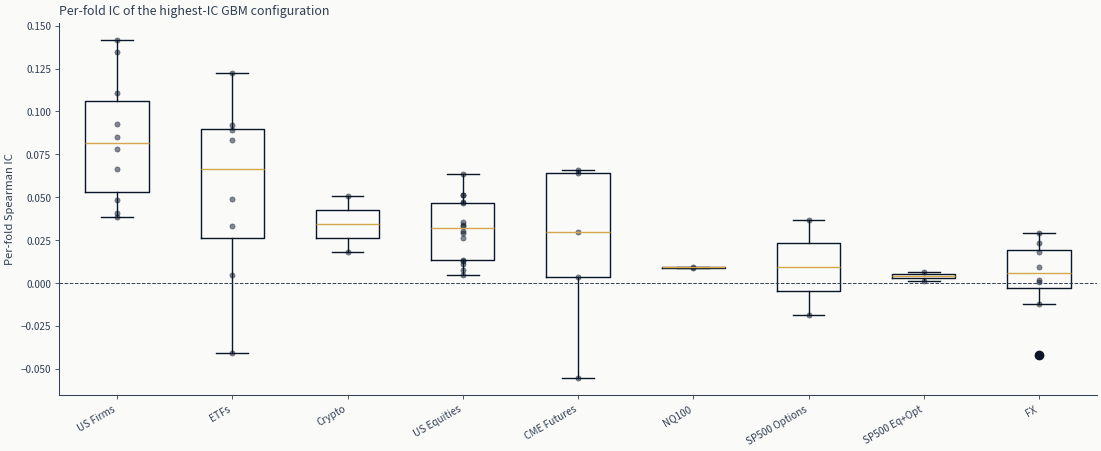

In [23]:
order = gbm_rank1.sort("ic_mean_daily", descending=True)["short_name"].to_list()
present = [c for c in order if c in gbm_fold["short_name"].unique().to_list()]

fig, ax = plt.subplots(figsize=(11, 4.5))
data = [gbm_fold.filter(pl.col("short_name") == cs)["ic"].to_numpy() for cs in present]
positions = np.arange(len(present))
ax.boxplot(data, positions=positions, widths=0.55, showfliers=True)
for i, arr in enumerate(data):
    if len(arr):
        ax.scatter(np.full(len(arr), i), arr, alpha=0.5, s=14, color=COLORS["blue"])
ax.axhline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
ax.set_xticks(positions)
ax.set_xticklabels(present, rotation=30, ha="right")
ax.set_ylabel("Per-fold Spearman IC")
ax.set_title("Per-fold IC of the highest-IC GBM configuration")
show_with_alt(
    fig,
    "Box plots of per-fold Spearman IC, one box per case study with the individual folds "
    "overlaid as points, against a dashed line at zero.",
)

In [24]:
gbm_positive_majority = gbm_fold_summary.filter(pl.col("pct_positive") > 0.5)[
    "short_name"
].to_list()
gbm_min_folds = int(gbm_fold_summary["n_folds"].min())
display(
    Markdown(
        f"**Computed fold diagnostic.** {len(gbm_positive_majority)} of "
        f"{gbm_fold_summary.height} selected GBM rows have a positive-fold majority "
        f"({', '.join(gbm_positive_majority) or 'none'}). The smallest exact fold panel "
        f"contains {gbm_min_folds} folds; inference remains attached to the daily HAC series."
    )
)

**Computed fold diagnostic.** 8 of 9 selected GBM rows have a positive-fold majority (US Firms, ETFs, Crypto, US Equities, CME Futures, NQ100, FX, SP500 Eq+Opt). The smallest exact fold panel contains 2 folds; inference remains attached to the daily HAC series.

### 4b. Validation → holdout decay dumbbell

Where the holdout retrain has been run, the validation-fold IC and the
nested-holdout IC are linked by a dumbbell. The case studies without GBM
holdout rows in the registry are excluded - the gap is explicit, not
silent.

In [25]:
HOLDOUT_QUERY = """
    SELECT p.prediction_hash, t.training_hash, t.config_name,
           pm.ic_mean_daily, pm.ic_ci_lo, pm.ic_ci_hi, pm.ic_n_days
    FROM prediction_metrics pm
    JOIN prediction_sets p ON pm.prediction_hash = p.prediction_hash
    JOIN training_runs t ON p.training_hash = t.training_hash
    WHERE t.family = ? AND t.label = ? AND t.config_name = ? AND p.split = 'holdout'
"""

In [26]:
def load_selected_holdout(case_study: str, family: str, config_name: str) -> dict | None:
    """Load one unique holdout row for the validation-selected configuration."""
    db_path = get_case_study_dir(case_study) / "run_log" / "registry.db"
    db = sqlite3.connect(f"file:{db_path}?mode=ro", uri=True)
    primary = PRIMARY_LABELS[case_study]
    rows = db.execute(
        HOLDOUT_QUERY,
        (family, primary, config_name),
    ).fetchall()
    db.close()
    valid = [
        row
        for row in rows
        if row[6] is not None
        and row[6] > 0
        and all(value is not None and np.isfinite(value) for value in row[3:7])
    ]
    if not valid:
        return None
    if len(valid) != 1:
        raise RuntimeError(f"Ambiguous holdout rows for {case_study}/{family}/{config_name}")
    row = valid[0]
    return {
        "case_study": case_study,
        "short_name": SHORT_NAMES[case_study],
        "label": primary,
        "prediction_hash": row[0],
        "training_hash": row[1],
        "config_name": row[2],
        "holdout_ic": row[3],
        "holdout_ci_lo": row[4],
        "holdout_ci_hi": row[5],
        "holdout_n_days": row[6],
    }

In [27]:
holdout_rows = []
for selected in gbm_rank1.iter_rows(named=True):
    holdout = load_selected_holdout(
        selected["case_study"],
        FAMILY,
        selected["config_name"],
    )
    if holdout is not None:
        holdout_rows.append(holdout)
holdout_df = pl.DataFrame(holdout_rows) if holdout_rows else pl.DataFrame()
print(
    f"GBM holdout for the validation-selected configuration is available for "
    f"{holdout_df.height} of {gbm_rank1.height} case studies."
)

GBM holdout for the validation-selected configuration is available for 0 of 9 case studies.


Available rows are aligned to the validation-selected configurations before plotting.

Segments and endpoint intervals show the direction and uncertainty of each change.

In [28]:
if not holdout_df.is_empty():
    val_lookup = {r["case_study"]: r for r in gbm_rank1.iter_rows(named=True)}
    decay_rows = []
    for r in holdout_rows:
        v = val_lookup.get(r["case_study"])
        if v is None:
            continue
        decay_rows.append(
            {
                "short_name": r["short_name"],
                "val_ic": v["ic_mean_daily"],
                "val_lo": v["ic_ci_lo"],
                "val_hi": v["ic_ci_hi"],
                "holdout_ic": r["holdout_ic"],
                "holdout_lo": r["holdout_ci_lo"],
                "holdout_hi": r["holdout_ci_hi"],
            }
        )
    decay_df = pl.DataFrame(decay_rows).sort("val_ic", descending=True)

Legend elements distinguish endpoints from the direction of each segment.

In [29]:
def holdout_legend() -> list[Line2D]:
    return [
        Line2D([0], [0], marker="o", color=COLORS["blue"], label="Validation"),
        Line2D([0], [0], marker="D", color=COLORS["amber"], label="Holdout"),
        Line2D([0], [0], color=COLORS["positive"], linewidth=2, label="Holdout ≥ Val"),
        Line2D([0], [0], color=COLORS["negative"], linewidth=2, label="Holdout < Val"),
    ]

The complete dumbbell is assembled in one rendering cell so Jupyter never
captures a partial plot.

In [30]:
def plot_holdout_decay(decay_df: pl.DataFrame) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(10, max(2.5, 0.5 * decay_df.height + 1)))
    y = np.arange(decay_df.height)
    val, ho = decay_df["val_ic"].to_numpy(), decay_df["holdout_ic"].to_numpy()
    val_lo, val_hi = decay_df["val_lo"].to_numpy(), decay_df["val_hi"].to_numpy()
    ho_lo, ho_hi = decay_df["holdout_lo"].to_numpy(), decay_df["holdout_hi"].to_numpy()
    for i in range(decay_df.height):
        color = COLORS["positive"] if ho[i] >= val[i] else COLORS["negative"]
        ax.plot([val[i], ho[i]], [i, i], color=color, linewidth=2.2, zorder=1)
    ax.errorbar(val, y, xerr=[val - val_lo, val_hi - val], fmt="o", color=COLORS["blue"], capsize=3)
    ax.errorbar(ho, y, xerr=[ho - ho_lo, ho_hi - ho], fmt="D", color=COLORS["amber"], capsize=3)
    ax.set_yticks(y)
    ax.set_yticklabels(decay_df["short_name"].to_list())
    ax.invert_yaxis()
    ax.axvline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
    ax.set_xlabel("Average daily IC (HAC 95 % CI)")
    ax.set_title("Validation and holdout IC for the highest-IC GBM configuration")
    ax.legend(handles=holdout_legend(), loc="best", frameon=False, fontsize=9)
    fig.tight_layout()
    return fig

The completed chart is rendered only when an exact selected holdout row exists.

In [31]:
if holdout_df.is_empty():
    display(
        Markdown(
            "**No holdout chart**: no case study in this run has a holdout result for its "
            "selected GBM configuration, so there is nothing to join a validation IC to."
        )
    )
else:
    fig = plot_holdout_decay(decay_df)
    show_with_alt(
        fig,
        "One horizontal line per case study joining its validation IC to its holdout IC, "
        "with a marker at each end, against a dashed line at zero.",
    )

**No holdout chart**: no case study in this run has a holdout result for its selected GBM configuration, so there is nothing to join a validation IC to.

In [32]:
holdout_names = holdout_df["short_name"].to_list() if not holdout_df.is_empty() else []
display(
    Markdown(
        f"**Computed holdout coverage.** The validation-selected GBM configuration has an "
        f"exact primary-label holdout row for {len(holdout_names)} of {gbm_rank1.height} "
        f"case studies ({', '.join(holdout_names) or 'none'}). No aggregate decay claim is "
        "made when this coverage is sparse."
    )
)

**Computed holdout coverage.** The validation-selected GBM configuration has an exact primary-label holdout row for 0 of 9 case studies (none). No aggregate decay claim is made when this coverage is sparse.

## 5. GBM versus Linear

Per case study, how much does GBM raise the average daily IC over the
strongest full-coverage linear configuration? Two descriptive views compare
the primary-label point estimates (5a) and the same delta across labels (5b).
We do not treat a pair of fold summaries as an uncertainty estimator; each
family's HAC interval comes from its chronological daily IC series.

In [33]:
linear_rank1 = collect_rank1_per_cs(
    CASE_STUDY_IDS,
    family=BASELINE_FAMILY,
)
linear_fold = collect_fold_ic_per_cs(linear_rank1)

`select_rank1` makes a family's own candidates comparable - same folds, same number of
days - but it does that within a family. Two families can each be internally
comparable and still be scored over different windows, which is what the day counts
printed below reveal. Subtracting across such a pair charges a window difference to
the model family, so those pairs are dropped.

In [34]:
delta_all = (
    gbm_rank1.select(
        "case_study",
        "short_name",
        pl.col("ic_mean_daily").alias("gbm_ic"),
        pl.col("ic_n_days").alias("gbm_days"),
        pl.col("prediction_hash").alias("gbm_prediction_hash"),
    )
    .join(
        linear_rank1.select(
            "case_study",
            pl.col("ic_mean_daily").alias("linear_ic"),
            pl.col("ic_n_days").alias("linear_days"),
            pl.col("prediction_hash").alias("linear_prediction_hash"),
        ),
        on="case_study",
        how="inner",
    )
    .with_columns(delta=pl.col("gbm_ic") - pl.col("linear_ic"))
    .sort("delta", descending=True)
)
delta_excluded = delta_all.filter(pl.col("gbm_days") != pl.col("linear_days"))
delta_primary = delta_all.filter(pl.col("gbm_days") == pl.col("linear_days"))

if not delta_excluded.is_empty():
    display(
        Markdown(
            f"**Excluded for unequal coverage:** {delta_excluded.height} of "
            f"{delta_all.height} case studies have a selected GBM and a selected Linear configuration scored "
            "over a different number of days. Their difference would mix a window "
            "effect into a family effect, so they are left out of the chart below."
        )
    )
    display(delta_excluded.select("short_name", "gbm_days", "linear_days"))

if delta_primary.is_empty():
    display(
        Markdown(
            "**No comparison is possible.** No case study has a selected GBM and a "
            "selected Linear configuration scored over the same number of days, so there "
            "is no matched primary-label delta to report."
        )
    )
else:
    print("Descriptive GBM minus Linear daily-IC delta at matched full coverage:")
    display(
        delta_primary.select(
            "short_name",
            pl.col("gbm_ic").round(4),
            pl.col("linear_ic").round(4),
            pl.col("delta").round(4),
            "gbm_days",
            "linear_days",
        )
    )

Descriptive GBM minus Linear daily-IC delta at matched full coverage:


short_name,gbm_ic,linear_ic,delta,gbm_days,linear_days
str,f64,f64,f64,f64,f64
"""US Firms""",0.0836,-0.0036,0.0872,110.0,110.0
"""Crypto""",0.0344,0.0008,0.0336,2189.0,2189.0
"""CME Futures""",0.0214,0.0037,0.0177,1285.0,1285.0
"""US Equities""",0.0311,0.0183,0.0128,4031.0,4031.0
"""ETFs""",0.0547,0.0437,0.011,1995.0,1995.0
"""SP500 Options""",0.0078,-0.0027,0.0105,478.0,478.0
"""SP500 Eq+Opt""",0.0039,-0.0009,0.0048,497.0,497.0
"""NQ100""",0.0091,0.0076,0.0015,78812.0,78812.0
"""FX""",0.0035,0.003,0.0006,2063.0,2063.0


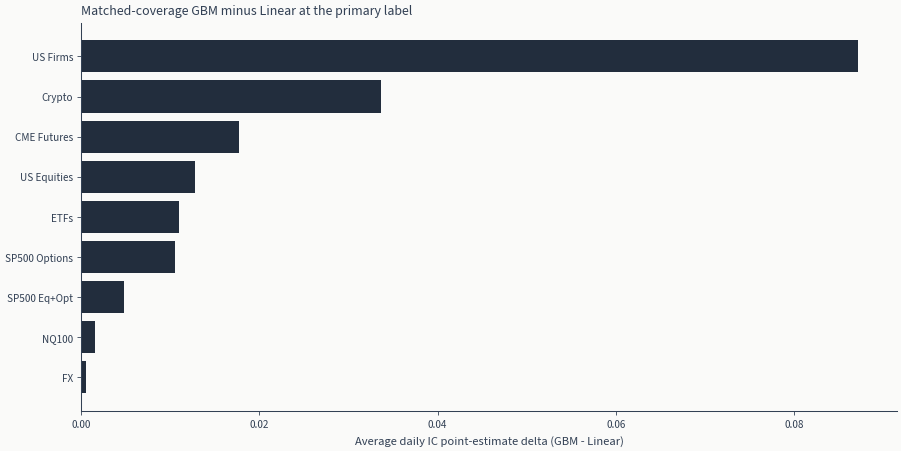

In [35]:
if not delta_primary.is_empty():
    fig, ax = plt.subplots(figsize=(9, 4.5))
    y = np.arange(delta_primary.height)
    delta = delta_primary["delta"].to_numpy()
    colors = [COLORS["blue"] if value >= 0 else COLORS["amber"] for value in delta]
    ax.barh(y, delta, color=colors, alpha=0.9)
    ax.axvline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
    ax.set_yticks(y)
    ax.set_yticklabels(delta_primary["short_name"].to_list())
    ax.invert_yaxis()
    ax.set_xlabel("Average daily IC point-estimate delta (GBM - Linear)")
    ax.set_title("Matched-coverage GBM minus Linear at the primary label")
    show_with_alt(
        fig,
        "Horizontal bars of the difference in average daily IC between the GBM and the "
        "linear model on matched coverage, one bar per case study, against a line at zero.",
    )

In [36]:
n_positive = delta_primary.filter(pl.col("delta") > 0).height
display(
    Markdown(
        f"**Computed comparison.** GBM has the higher daily-IC point estimate in "
        f"{n_positive} of the {delta_primary.height} case studies whose two selections were "
        f"scored over the same number of days, out of {delta_all.height} with a selection in "
        "both families. This chart is descriptive: the two model families have separate "
        "daily-series HAC intervals, so no paired-fold confidence claim is attached to "
        "their difference."
    )
)

**Computed comparison.** GBM has the higher daily-IC point estimate in 9 of the 9 case studies whose two selections were scored over the same number of days, out of 9 with a selection in both families. This chart is descriptive: the two model families have separate daily-series HAC intervals, so no paired-fold confidence claim is attached to their difference.

### 5b. GBM minus Linear, faceted by label

The primary-label delta is a single horizon per case study. Faceting
across all labels where both families trained shows whether the GBM
advantage (or absence thereof) is consistent across horizons within a
panel.

In [37]:
HORIZON_EXCLUSIONS = {
    (
        "nasdaq100_microstructure",
        "gbm",
        "fwd_ret_5m",
    ): "two complete GBM candidates tie for rank one in the provisional registry",
    (
        "sp500_equity_option_analytics",
        "linear",
        "fwd_ret_risk_adj_5d",
    ): "five complete Linear candidates tie for rank one",
}


def regression_labels(cs: str, family: str) -> list[str]:
    df = load_metrics_from_registry(cs, families=[family])
    if df.is_empty():
        return []
    return [
        lbl
        for lbl in df["label"].unique().to_list()
        if lbl is not None
        and lbl.startswith("fwd_ret_")
        and "spot" not in lbl
        and (cs, family, lbl) not in HORIZON_EXCLUSIONS
    ]

Both families pass through the same complete-coverage selector, which makes
each family's selection comparable against its own alternatives. It does not make
the two selections comparable to each other, so the join below keeps only the
cells where both were scored over the same number of days.

In [38]:
gbm_horizon = collect_multi_label_per_cs(
    CASE_STUDY_IDS,
    family=FAMILY,
    labels=lambda cs: regression_labels(cs, FAMILY),
)
lin_horizon = collect_multi_label_per_cs(
    CASE_STUDY_IDS,
    family=BASELINE_FAMILY,
    labels=lambda cs: regression_labels(cs, BASELINE_FAMILY),
)

Two optional family-label cells are ambiguous: NASDAQ-100 GBM
`fwd_ret_5m` has two complete rank-one candidates, while the S&P
equity-option Linear `fwd_ret_risk_adj_5d` cell has five. Those family-label
cells are excluded rather than resolved arbitrarily. Primary labels and all
unambiguous family-label cells remain in the notebook.

Matched case-study and label rows form the descriptive family-difference panel.

In [39]:
facet_all = (
    gbm_horizon.select(
        "case_study",
        "short_name",
        "label",
        pl.col("ic_mean_daily").alias("gbm_ic"),
        pl.col("ic_n_days").alias("gbm_days"),
    )
    .join(
        lin_horizon.select(
            "case_study",
            "label",
            pl.col("ic_mean_daily").alias("lin_ic"),
            pl.col("ic_n_days").alias("lin_days"),
        ),
        on=["case_study", "label"],
        how="inner",
    )
    .with_columns(delta=pl.col("gbm_ic") - pl.col("lin_ic"))
    .sort(["short_name", "label"])
)
# Same cross-family coverage rule as 5a: each family's selection is comparable
# within its own family, which does not make the two comparable to each other.
facet_excluded = facet_all.filter(pl.col("gbm_days") != pl.col("lin_days"))
facet_df = facet_all.filter(pl.col("gbm_days") == pl.col("lin_days"))

if not facet_excluded.is_empty():
    display(
        Markdown(
            f"**Excluded for unequal coverage:** {facet_excluded.height} of "
            f"{facet_all.height} (case study, label) cells pair selections scored over a "
            "different number of days."
        )
    )
    display(facet_excluded.select("short_name", "label", "gbm_days", "lin_days"))

if facet_df.is_empty():
    display(
        Markdown(
            "**No comparison is possible.** No (case study, label) cell pairs a selected "
            "GBM and a selected Linear configuration scored over the same number of days."
        )
    )
else:
    print(f"GBM-minus-Linear deltas across {facet_df.height} matched-coverage (CS, label) cells:")
    display(
        facet_df.select(
            "short_name",
            "label",
            pl.col("gbm_ic").round(4).alias("gbm"),
            pl.col("lin_ic").round(4).alias("lin"),
            pl.col("delta").round(4).alias("delta"),
            "gbm_days",
            "lin_days",
        )
    )

GBM-minus-Linear deltas across 18 matched-coverage (CS, label) cells:


short_name,label,gbm,lin,delta,gbm_days,lin_days
str,str,f64,f64,f64,f64,f64
"""CME Futures""","""fwd_ret_21d""",-0.0011,0.0435,-0.0445,1269.0,1269.0
"""CME Futures""","""fwd_ret_5d""",0.0214,0.0037,0.0177,1285.0,1285.0
"""Crypto""","""fwd_ret_24h""",0.0357,-0.0126,0.0483,2187.0,2187.0
"""Crypto""","""fwd_ret_8h""",0.0344,0.0008,0.0336,2189.0,2189.0
"""ETFs""","""fwd_ret_21d""",0.0547,0.0437,0.011,1995.0,1995.0
…,…,…,…,…,…,…
"""US Equities""","""fwd_ret_1d""",0.0311,0.0183,0.0128,4031.0,4031.0
"""US Equities""","""fwd_ret_21d""",0.041,0.0109,0.0301,4011.0,4011.0
"""US Equities""","""fwd_ret_5d""",0.0345,0.0189,0.0155,4027.0,4027.0


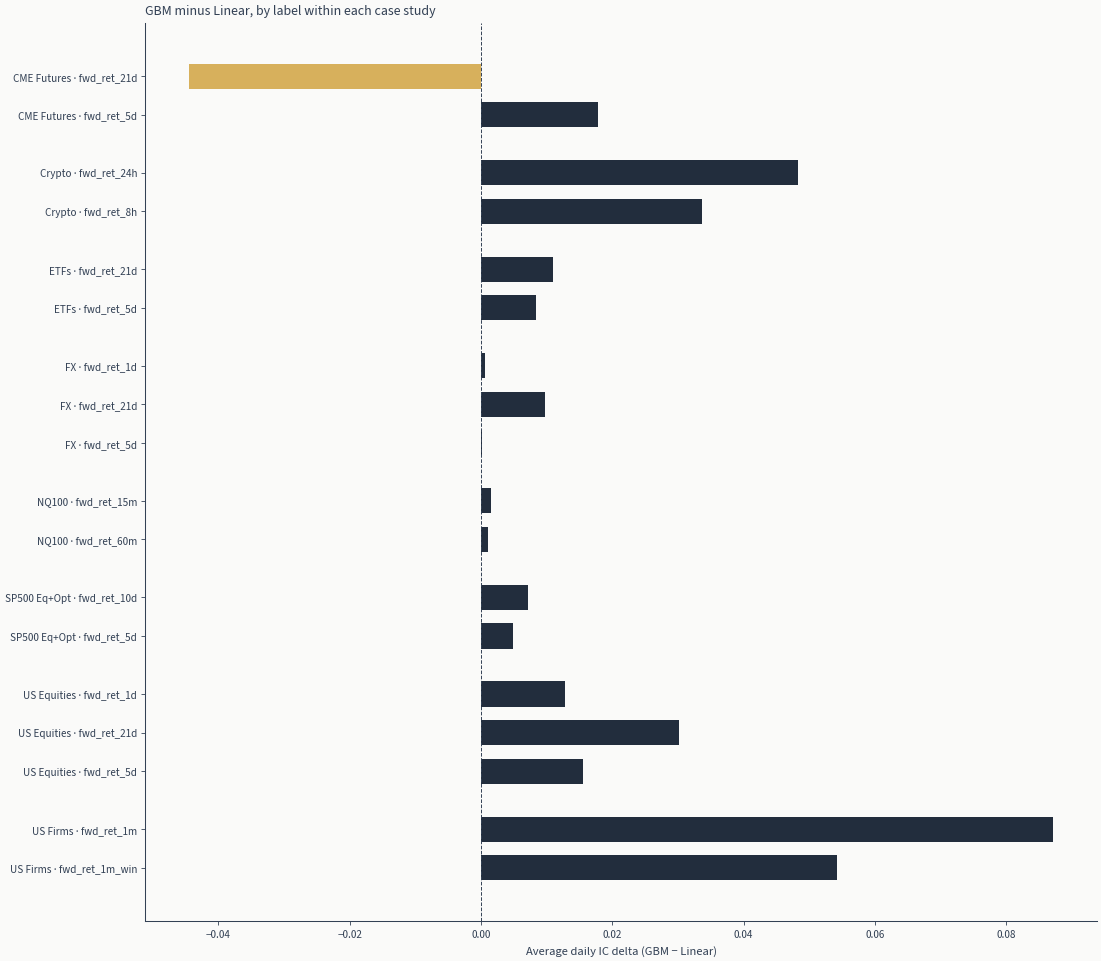

In [40]:
if not facet_df.is_empty():
    cs_sorted = sorted(facet_df["short_name"].unique().to_list())
    fig, ax = plt.subplots(figsize=(11, max(3.5, 0.45 * facet_df.height + 1.5)))
    y_off = 0
    yticks, ylabels = [], []
    for cs in cs_sorted:
        sub = facet_df.filter(pl.col("short_name") == cs)
        for r in sub.iter_rows(named=True):
            color = COLORS["blue"] if r["delta"] >= 0 else COLORS["amber"]
            ax.barh(y_off, r["delta"], color=color, height=0.65, alpha=0.9)
            yticks.append(y_off)
            ylabels.append(f"{cs} · {r['label']}")
            y_off += 1
        y_off += 0.5  # gap between case studies
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=8)
    ax.invert_yaxis()
    ax.axvline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
    ax.set_xlabel("Average daily IC delta (GBM − Linear)")
    ax.set_title("GBM minus Linear, by label within each case study")
    show_with_alt(
        fig,
        "Horizontal bars of the IC difference between the GBM and the linear model, one "
        "bar per label grouped by case study, against a line at zero.",
    )

In [41]:
if facet_df.is_empty():
    display(
        Markdown(
            "**No horizon comparison.** Every (case study, label) cell paired selections "
            "scored over a different number of days, so there is no matched range to "
            "report."
        )
    )
else:
    facet_positive = facet_df.filter(pl.col("delta") > 0).height
    largest_facet = facet_df.sort("delta", descending=True).row(0, named=True)
    smallest_facet = facet_df.sort("delta").row(0, named=True)
    display(
        Markdown(
            f"**Computed horizon comparison.** GBM has the higher point estimate in "
            f"{facet_positive} of {facet_df.height} matched case-study/label cells. The range "
            f"runs from {smallest_facet['short_name']} {smallest_facet['label']} "
            f"({smallest_facet['delta']:+.4f}) to {largest_facet['short_name']} "
            f"{largest_facet['label']} ({largest_facet['delta']:+.4f})."
        )
    )

**Computed horizon comparison.** GBM has the higher point estimate in 17 of 18 matched case-study/label cells. The range runs from CME Futures fwd_ret_21d (-0.0445) to US Firms fwd_ret_1m (+0.0872).

## 6. Multi-Label Horizon and Metric Symmetry

### 6a. GBM IC across regression labels per case study

In [42]:
HORIZON_DAYS = {
    "fwd_ret_5m": 5 / (6.5 * 60),
    "fwd_ret_15m": 15 / (6.5 * 60),
    "fwd_ret_60m": 60 / (6.5 * 60),
    "fwd_ret_8h": 1.0 / 3,
    "fwd_ret_24h": 1.0,
    "fwd_ret_1d": 1.0,
    "fwd_ret_5d": 5.0,
    "fwd_ret_10d": 10.0,
    "fwd_ret_21d": 21.0,
    "fwd_ret_1m": 21.0,
    "fwd_ret_3m": 63.0,
    "fwd_ret_1m_win": 21.0,
    "fwd_ret_risk_adj_5d": 5.0,
}

Only panels with at least two mapped horizons enter the log-scale comparison.

The sibling figure in Chapter 13 also drops cells whose scored folds cover only part of
the case study's modelling grid, because joining a partial-grid point to a full-grid one
on a shared IC axis reads as one quantity moving with horizon. `gbm_horizon` carries the
same `covers_fold_grid` column and this cell does not filter on it, because no gbm or
linear run can be partial: `us_equities_panel/12_dl_weekly` is the only notebook in the
corpus with a non-zero `MAX_FOLDS`, and it is a deep-learning notebook. Give any gbm or
linear notebook a fold reduction and this cell needs Chapter 13's retain-and-report
split before it is read again.

In [43]:
plot_horizon = gbm_horizon.with_columns(
    horizon_days=pl.col("label").replace_strict(HORIZON_DAYS, default=None).cast(pl.Float64),
).filter(pl.col("horizon_days").is_not_null())
multi_cs = (
    plot_horizon.group_by("short_name", maintain_order=True)
    .len()
    .filter(pl.col("len") >= 2)["short_name"]
    .to_list()
)
plot_horizon = plot_horizon.filter(pl.col("short_name").is_in(multi_cs))

Each line carries its own HAC band; marker and line style supplement the compact palette.

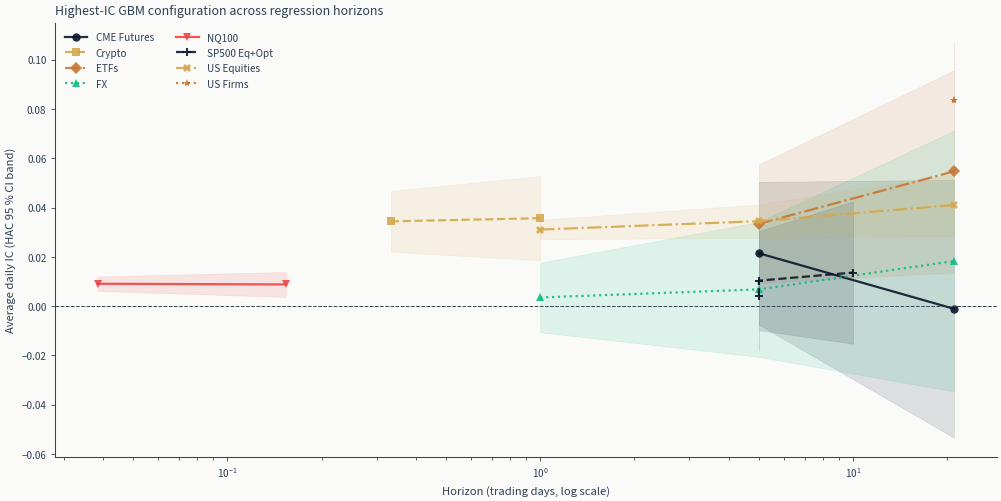

In [44]:
if plot_horizon.height > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    palette = ml4t_palette(5, categorical=True)
    cs_sorted = sorted(plot_horizon["short_name"].unique().to_list())
    markers = ["o", "s", "D", "^", "v", "P", "X", "*"]
    linestyles = ["-", "--", "-.", ":", "-", "--", "-.", ":"]
    for idx, cs in enumerate(cs_sorted):
        # Sorted on (horizon_days, label): two targets can share a horizon, and their tie
        # order decides which point the line reaches first, so sorting on the horizon
        # alone made the figure differ run to run.
        sub = plot_horizon.filter(pl.col("short_name") == cs).sort(["horizon_days", "label"])
        if sub.height < 2:
            continue
        x = sub["horizon_days"].to_numpy()
        ic = sub["ic_mean_daily"].to_numpy()
        lo = sub["ic_ci_lo"].to_numpy()
        hi = sub["ic_ci_hi"].to_numpy()
        color = palette[idx % len(palette)]
        ax.fill_between(x, lo, hi, color=color, alpha=0.12)
        ax.plot(
            x,
            ic,
            marker=markers[idx % len(markers)],
            linestyle=linestyles[idx % len(linestyles)],
            color=color,
            label=cs,
            linewidth=1.6,
            markersize=6,
            alpha=0.9,
        )
    ax.set_xscale("log")
    ax.set_xlabel("Horizon (trading days, log scale)")
    ax.set_ylabel("Average daily IC (HAC 95 % CI band)")
    ax.axhline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
    ax.set_title("Highest-IC GBM configuration across regression horizons")
    ax.legend(loc="best", frameon=False, fontsize=8, ncol=2)
    show_with_alt(
        fig,
        "Average daily IC against label horizon on a log axis, one line per case study, "
        "against a line at zero.",
    )

In [45]:
horizon_ranges = (
    plot_horizon.group_by("short_name", maintain_order=True)
    .agg(
        n_horizons=pl.len(),
        min_ic=pl.col("ic_mean_daily").min(),
        max_ic=pl.col("ic_mean_daily").max(),
    )
    .with_columns(ic_range=pl.col("max_ic") - pl.col("min_ic"))
    .sort("ic_range", descending=True)
)
display(
    Markdown(
        f"**Computed horizon coverage.** {horizon_ranges.height} case studies have at least "
        "two comparable regression horizons. Their exact IC ranges are shown above; no "
        "cross-horizon trend is asserted for single-horizon panels."
    )
)

**Computed horizon coverage.** 8 case studies have at least two comparable regression horizons. Their exact IC ranges are shown above; no cross-horizon trend is asserted for single-horizon panels.

### 6b. Classification ↔ regression metric symmetry

A GBM trained on a continuous return label has a regression score; the
same model class can be trained on the binary direction label of the
same horizon. Two symmetric questions arise on the case studies that
carry binary direction labels paired to the regression labels:

- **Direction A** - the GBM classification model's score, evaluated as
  IC against the *continuous* return, asks whether the directional
  classifier is also a useful *cross-sectional ranker*. Read from
  `prediction_metrics.ic_mean_daily` for `task_type='classification'` rows.
- **Direction B** - the GBM regression model's score, evaluated as AUC
  against the *binary* direction, asks whether the continuous regression
  score is also a useful *binary classifier*. Computed on the fly here
  from raw OOF predictions.

The pairs are discovered from the registry rather than listed here. A case study
qualifies when this family has registered validation predictions for a
`fwd_ret_<horizon>` label and for a `fwd_dir_<horizon>` or `fwd_class_<horizon>`
label at the same horizon, and the direction label's own surface is binary. A
ternary label needs a multiclass score and is out of scope, so it is skipped by
measuring its domain and naming it, not by being absent from a list: the previous
hand-written literal had lost `us_firm_characteristics` and reported a full count
of itself, and the comment that stood here called `fwd_class_1m` ternary when its
domain is {0, 1}. This mirrors Ch11 §6b for the linear family.

In [46]:
SYMMETRY_PAIRS, SYMMETRY_SKIPS = discover_symmetry_pairs(CASE_STUDY_IDS, FAMILY)
for line in SYMMETRY_SKIPS:
    print(f"  skipped {line}")
print(
    f"{sum(len(pairs) for pairs in SYMMETRY_PAIRS.values())} matched label pairs across "
    f"{len(SYMMETRY_PAIRS)} case studies"
)

  skipped crypto_perps_funding/fwd_dir_8h_3c: domain [-1, 0, 1] is not binary, a multi-class AUC is out of scope here
  skipped nasdaq100_microstructure/fwd_dir_15m: domain [-1, 0, 1] is not binary, a multi-class AUC is out of scope here
4 matched label pairs across 3 case studies


Binary labels align on canonical timestamp and symbol before the regression
score is evaluated as a direction classifier.

In [47]:


def load_binary_label(cs: str, dir_label: str) -> pl.DataFrame:
    p = get_case_study_dir(cs) / "labels" / f"{dir_label}.parquet"
    if not p.exists():
        return pl.DataFrame()
    df = pl.read_parquet(p)
    return df.rename({dir_label: "y_dir"}).select("timestamp", "symbol", "y_dir")

In [48]:
def gbm_direction_b_auc(selected: dict, dir_label: str) -> dict | None:
    cs = selected["case_study"]
    reg_label = selected["label"]
    preds = load_predictions(
        cs,
        family=FAMILY,
        label=reg_label,
        config_name=selected["config_name"],
        checkpoint_value=selected["checkpoint_value"],
        split="validation",
    ).filter(pl.col("prediction_hash") == selected["prediction_hash"])
    if preds.height == 0:
        return None
    dir_df = load_binary_label(cs, dir_label)
    if dir_df.is_empty():
        return None
    canonical_types = {"timestamp": pl.Datetime("ms"), "symbol": pl.Utf8}
    for column, dtype in canonical_types.items():
        if preds[column].dtype != dir_df[column].dtype:
            preds = preds.with_columns(pl.col(column).cast(dtype))
            dir_df = dir_df.with_columns(pl.col(column).cast(dtype))
    merged = preds.join(dir_df, on=["timestamp", "symbol"], how="inner")
    domain = set(merged["y_dir"].unique().drop_nulls().to_list())
    if not domain.issubset({0, 1}):
        print(f"  SKIP {cs}/{dir_label}: y_dir domain {domain} is not binary {{0,1}}")
        return None
    merged = merged.filter(pl.col("y_dir").is_in([0, 1]) & pl.col("y_score").is_not_null())
    if merged.height == 0 or merged["y_dir"].n_unique() < 2:
        return None
    auc = float(roc_auc_score(merged["y_dir"].to_numpy(), merged["y_score"].to_numpy()))
    return {
        "case_study": cs,
        "short_name": SHORT_NAMES[cs],
        "reg_label": reg_label,
        "dir_label": dir_label,
        "reg_config": selected["config_name"],
        "reg_prediction_hash": selected["prediction_hash"],
        "reg_score_auc": auc,
        "n": merged.height,
    }

In [49]:
direction_labels = {
    cs: [direction_label for _, direction_label in pairs] for cs, pairs in SYMMETRY_PAIRS.items()
}
direction_rank1 = collect_multi_label_per_cs(
    SYMMETRY_PAIRS,
    family=FAMILY,
    labels=lambda cs: direction_labels[cs],
)

Direction A comes from the selected classification row; Direction B uses the
exact selected regression prediction hash against the paired binary label.

In [50]:
sym_rows = []
for cs, pairs in SYMMETRY_PAIRS.items():
    for reg_lbl, dir_lbl in pairs:
        cls_ic = cls_lo = cls_hi = cls_t = cls_cfg = None
        cls_auc = cls_auc_lo = cls_auc_hi = None
        cls_selected = direction_rank1.filter(
            (pl.col("case_study") == cs) & (pl.col("label") == dir_lbl)
        )
        if not cls_selected.is_empty():
            top = cls_selected.row(0, named=True)
            cls_ic = top["ic_mean_daily"]
            cls_lo = top.get("ic_ci_lo")
            cls_hi = top.get("ic_ci_hi")
            cls_t = top.get("ic_t_hac")
            cls_cfg = top["config_name"]
            # The classifier's AUC against its own direction label. It is the third
            # column of the book's Table 12.4 and sits in the same prediction_metrics
            # row as the IC above; until 2026-09-18 the selector did not read it, so
            # this notebook published a table it could not reproduce from its own output.
            cls_auc = top.get("auc_mean_daily")
            cls_auc_lo = top.get("auc_ci_lo")
            cls_auc_hi = top.get("auc_ci_hi")
        reg_selected = gbm_horizon.filter(
            (pl.col("case_study") == cs) & (pl.col("label") == reg_lbl)
        )
        b = (
            gbm_direction_b_auc(reg_selected.row(0, named=True), dir_lbl)
            if not reg_selected.is_empty()
            else None
        )
        sym_rows.append(
            {
                "short_name": SHORT_NAMES[cs],
                "reg_label": reg_lbl,
                "dir_label": dir_lbl,
                "cls_config": cls_cfg,
                "cls_score_ic": cls_ic,
                "cls_score_ic_lo": cls_lo,
                "cls_score_ic_hi": cls_hi,
                "cls_score_ic_t": cls_t,
                "cls_score_auc": cls_auc,
                "cls_score_auc_lo": cls_auc_lo,
                "cls_score_auc_hi": cls_auc_hi,
                "reg_config": (b or {}).get("reg_config"),
                "reg_score_auc": (b or {}).get("reg_score_auc"),
                "n_b": (b or {}).get("n"),
            }
        )

The combined table keeps both metric directions and their selected identities visible.

In [51]:

# A full schema, not schema_overrides. Discovery can legitimately return nothing - every
# declared pair skipped, or a registry with no classification runs for this family - and a
# frame built from an empty list with partial overrides has no string columns at all, so
# the selection below raises ColumnNotFoundError and the skip reasons this section exists
# to print never reach the reader. An empty frame with the right columns renders as an
# empty table, which is the correct answer.
sym_df = pl.DataFrame(sym_rows, schema=SYMMETRY_TABLE_SCHEMA)
print(
    "Direction A (GBM classification score → IC), the classifier's own AUC, "
    "and Direction B (GBM regression score → AUC):"
)
sym_df.select(
    "short_name",
    "reg_label",
    "dir_label",
    pl.col("cls_score_ic").round(4).alias("A_ic"),
    pl.col("cls_score_ic_lo").round(4).alias("A_lo"),
    pl.col("cls_score_ic_hi").round(4).alias("A_hi"),
    pl.col("cls_score_ic_t").round(2).alias("A_t"),
    pl.col("cls_score_auc").round(4).alias("native_auc"),
    pl.col("cls_score_auc_lo").round(4).alias("native_lo"),
    pl.col("cls_score_auc_hi").round(4).alias("native_hi"),
    pl.col("reg_score_auc").round(4).alias("B_auc"),
)

Direction A (GBM classification score → IC), the classifier's own AUC, and Direction B (GBM regression score → AUC):


short_name,reg_label,dir_label,A_ic,A_lo,A_hi,A_t,native_auc,native_lo,native_hi,B_auc
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""Crypto""","""fwd_ret_8h""","""fwd_dir_8h""",0.0253,0.014,0.0366,4.39,0.5088,0.4982,0.5194,0.5154
"""SP500 Eq+Opt""","""fwd_ret_10d""","""fwd_dir_10d""",0.0011,-0.0165,0.0187,0.12,0.5053,0.4956,0.515,0.5154
"""SP500 Eq+Opt""","""fwd_ret_5d""","""fwd_dir_5d""",0.0043,-0.0117,0.0203,0.53,0.5069,0.4975,0.5162,0.4968
"""US Firms""","""fwd_ret_1m""","""fwd_class_1m""",0.084,0.0605,0.1076,7.08,0.5429,0.5317,0.5541,0.5408


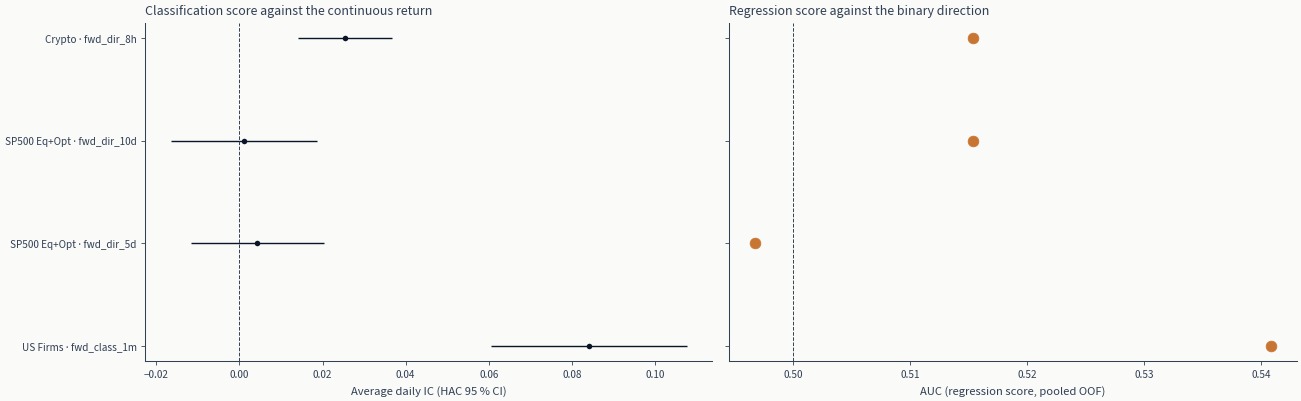

In [52]:
if sym_df.is_empty():
    raise RuntimeError(
        "no declared regression/direction pair qualified, so there is nothing to compare. "
        f"Skipped: {'; '.join(SYMMETRY_SKIPS) or 'nothing'}"
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
labels_y = [f"{r['short_name']} · {r['dir_label']}" for r in sym_df.iter_rows(named=True)]
y = np.arange(sym_df.height)

ax = axes[0]
ic = sym_df["cls_score_ic"].to_numpy()
lo = sym_df["cls_score_ic_lo"].to_numpy()
hi = sym_df["cls_score_ic_hi"].to_numpy()
ax.errorbar(
    ic,
    y,
    xerr=[ic - lo, hi - ic],
    fmt="o",
    color=COLORS["blue"],
    capsize=3,
    lw=1,
)
ax.axvline(0, color=COLORS["neutral"], lw=0.7, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(labels_y)
ax.invert_yaxis()
ax.set_xlabel("Average daily IC (HAC 95 % CI)")
ax.set_title("Classification score against the continuous return")

ax = axes[1]
auc = sym_df["reg_score_auc"].to_numpy()
ax.scatter(auc, y, color=COLORS["copper"], s=60, zorder=3)
ax.axvline(0.5, color=COLORS["neutral"], lw=0.7, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels([])
ax.invert_yaxis()
ax.set_xlabel("AUC (regression score, pooled OOF)")
ax.set_title("Regression score against the binary direction")

show_with_alt(
    fig,
    "Two panels. Left: the classification score's IC against the continuous return, one "
    "row per pair with its HAC interval, against a line at zero. Right: the regression "
    "score's pooled out-of-fold AUC against the binary direction, against a line at one "
    "half.",
)

In [53]:
direction_a_positive = sym_df.filter(pl.col("cls_score_ic") > 0).height
direction_b_valid = sym_df.filter(pl.col("reg_score_auc").is_not_null())
native_valid = sym_df.filter(pl.col("cls_score_auc").is_not_null())
native_clears = native_valid.filter(pl.col("cls_score_auc_lo") > 0.5).height
# A count over the pairs that happen to be present is not a count over the corpus, so the
# skipped candidates are named in the same sentence rather than left to the log above.
skip_note = (
    f", with {len(SYMMETRY_SKIPS)} candidate pair(s) skipped ({'; '.join(SYMMETRY_SKIPS)})"
    if SYMMETRY_SKIPS
    else ", with no candidate pair skipped"
)
max_auc_distance = (
    float((direction_b_valid["reg_score_auc"] - 0.5).abs().max())
    if not direction_b_valid.is_empty()
    else float("nan")
)
display(
    Markdown(
        f"**Computed metric symmetry.** Direction A is positive in {direction_a_positive} of "
        f"{sym_df.height} matched cells, discovered from the registry rather than declared"
        f"{skip_note}. The classifier's own AUC clears one half on "
        f"{native_clears} of {native_valid.height} cells. Direction B is available in "
        f"{direction_b_valid.height} cells, with maximum absolute distance from chance of "
        f"{max_auc_distance:.4f}."
    )
)

**Computed metric symmetry.** Direction A is positive in 4 of 4 matched cells, discovered from the registry rather than declared, with 2 candidate pair(s) skipped (crypto_perps_funding/fwd_dir_8h_3c: domain [-1, 0, 1] is not binary, a multi-class AUC is out of scope here; nasdaq100_microstructure/fwd_dir_15m: domain [-1, 0, 1] is not binary, a multi-class AUC is out of scope here). The classifier's own AUC clears one half on 1 of 4 cells. Direction B is available in 4 cells, with maximum absolute distance from chance of 0.0408.

## 7. Interpretability

Three diagnostics read the fold models each selected run saved: feature-importance
rank shift against the linear baseline (7a), per-fold rank stability of GBM
importances (7b), and the TabM-vs-GBM-vs-Linear three-way picture (7c).

In [54]:
NON_FEATURE_COLS = {"timestamp", "symbol", "stock_id", "product", "position", "instrument_id"}
IMPORTANCE_CASES = ["etfs", "sp500_options", "us_firm_characteristics", "us_equities_panel"]

# A penalized fit drives coefficients to exactly zero, and a feature the model does not
# use has no rank. Ranking those alongside the rest would fill the comparison with ties
# broken by feature name, so they come out and the surviving count is reported.
ZERO_TOL = 1e-12


def _load_linear_importance(cs: str, training_hash: str) -> dict[str, float]:
    """Mean absolute coefficient per feature, over the folds of one linear training run.

    The pipeline stores each fold's fitted estimator under the run's `models`
    directory; the coefficients live on the estimator rather than in a table of
    their own. Features the model zeroed in every fold are dropped.
    """
    models_dir = get_case_study_dir(cs) / "run_log" / "training" / training_hash / "models"
    fold_paths = sorted(models_dir.glob("fold_*.joblib")) if models_dir.exists() else []
    rows = []
    for fold_path in fold_paths:
        with warnings.catch_warnings():
            # Read for `coef_` only, never to predict, so an estimator pickled by a
            # different scikit-learn is safe to unpickle here.
            warnings.filterwarnings(
                "ignore", category=InconsistentVersionWarning, module="sklearn.base"
            )
            payload = joblib.load(fold_path)
        names = list(payload["feature_names"])
        coef = np.asarray(payload["model"].coef_, dtype=float).ravel()
        if coef.size != len(names):
            raise RuntimeError(
                f"{cs} {training_hash}: {fold_path.name} carries {coef.size} coefficients "
                f"against {len(names)} feature names, so the two cannot be paired."
            )
        rows.extend(
            {"feature": name, "abs_coef": abs(float(value))}
            for name, value in zip(names, coef, strict=True)
        )
    if not rows:
        return {}
    return dict(
        pl.DataFrame(rows)
        .group_by("feature", maintain_order=True)
        .agg(pl.col("abs_coef").mean())
        .filter(pl.col("abs_coef") > ZERO_TOL)
        .sort("abs_coef", descending=True)
        .iter_rows()
    )

Rank dictionaries use the same feature intersection for both families.

In [55]:
def _feature_ranks(
    gbm_imp_df: pl.DataFrame,
    linear_imp: dict[str, float],
) -> tuple[dict[str, int], dict[str, int]]:
    gbm_imp = dict(
        gbm_imp_df.group_by("feature", maintain_order=True)
        .agg(pl.col("importance").mean().alias("imp"))
        .iter_rows()
    )
    # Ties break by feature name rather than by set iteration order: gain importances tie
    # readily, and with per-process string hashing the same registries produced different
    # ranks from one run to the next.
    common = sorted(set(gbm_imp) & set(linear_imp))
    gbm_order = sorted(common, key=lambda feature: (-gbm_imp[feature], feature))
    linear_order = sorted(common, key=lambda feature: (-linear_imp[feature], feature))
    return (
        {feature: rank for rank, feature in enumerate(gbm_order, 1)},
        {feature: rank for rank, feature in enumerate(linear_order, 1)},
    )

### 7a. Feature importance - GBM versus the linear baseline

For each case study that saved both boosters and linear fold models, features are
ranked by GBM gain importance and by the linear model's mean |coefficient|, both
averaged across folds. The rank shift `linear_rank − gbm_rank` is positive for
features the GBM promotes over the linear model (typically interaction or regime
features) and negative for features the linear model promotes (typically monotonic
predictors). The baseline is whichever linear configuration validation selected, so
a sparse fit such as a lasso contributes only the features it kept; `n_common_features`
says how many that leaves.

In [56]:
def feature_rank_shift(cs: str) -> dict | None:
    gbm_selected = gbm_rank1.filter(pl.col("case_study") == cs)
    linear_selected = linear_rank1.filter(pl.col("case_study") == cs)
    if gbm_selected.is_empty() or linear_selected.is_empty():
        return None
    gbm_row = gbm_selected.row(0, named=True)
    linear_row = linear_selected.row(0, named=True)
    gbm_imp_df = load_gbm_feature_importance(
        cs,
        gbm_row["training_hash"],
        gbm_row["config_name"],
        top_n=50,
        num_iteration=gbm_row["checkpoint_value"],
    )
    if gbm_imp_df.is_empty():
        return None
    linear_imp = _load_linear_importance(cs, linear_row["training_hash"])
    gbm_ranks, linear_ranks = _feature_ranks(gbm_imp_df, linear_imp)
    if not gbm_ranks:
        return None
    shifts = pl.DataFrame(
        [
            {
                "feature": f,
                "gbm_rank": gbm_ranks[f],
                "linear_rank": linear_ranks[f],
                "rank_shift": linear_ranks[f] - gbm_ranks[f],
            }
            for f in gbm_ranks
        ]
    )
    min_shift = shifts["rank_shift"].min()
    return {
        "short_name": SHORT_NAMES[cs],
        "n_common_features": shifts.height,
        "median_abs_shift": float(shifts["rank_shift"].abs().median()),
        "max_gbm_promotion": int(shifts["rank_shift"].max() or 0),
        "max_linear_promotion": int(-min_shift if min_shift else 0),
        "_shifts": shifts,
    }

Apply the comparison only where both exact selected artifact sets exist.

In [57]:
rank_shift_summary = [
    entry for cs in IMPORTANCE_CASES if (entry := feature_rank_shift(cs)) is not None
]

print(f"Computed GBM-vs-linear rank shifts for {len(rank_shift_summary)} case studies.")
shift_summary_df = (
    pl.DataFrame(
        [{k: v for k, v in r.items() if not k.startswith("_")} for r in rank_shift_summary]
    )
    if rank_shift_summary
    else pl.DataFrame()
)
shift_summary_df

Computed GBM-vs-linear rank shifts for 4 case studies.


short_name,n_common_features,median_abs_shift,max_gbm_promotion,max_linear_promotion
str,i64,f64,i64,i64
"""ETFs""",46,8.5,35,33
"""SP500 Options""",46,8.0,27,32
"""US Firms""",5,1.0,3,2
"""US Equities""",50,11.5,31,33


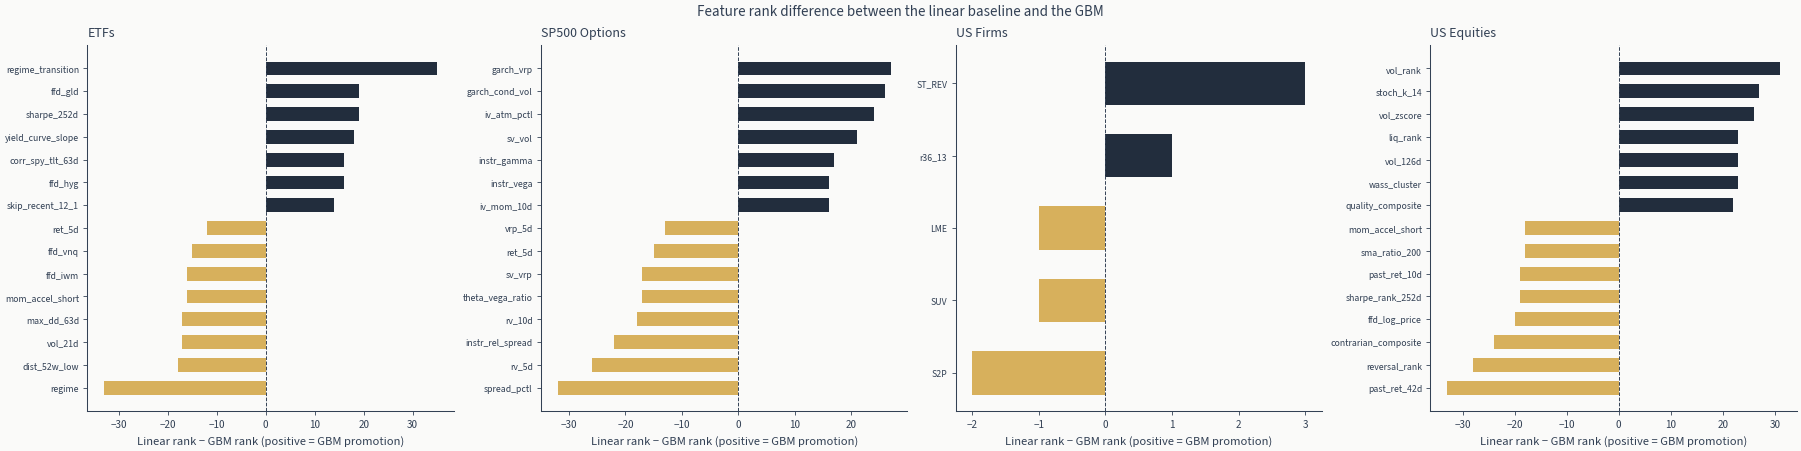

In [58]:
if not rank_shift_summary:
    display(
        Markdown(
            "**No promotion chart**: no case study has both a GBM importance artifact and "
            "linear fold models, so there is no pair of rankings to difference."
        )
    )
else:
    # Each panel ranks its own case study's features, so the y axes carry different
    # categories and cannot be shared: one shared axis would draw the last panel's
    # feature names beside every panel's bars.
    fig, axes = plt.subplots(
        1,
        len(rank_shift_summary),
        figsize=(4.5 * len(rank_shift_summary), 4.5),
    )
    if len(rank_shift_summary) == 1:
        axes = [axes]
    for ax, entry in zip(axes, rank_shift_summary, strict=False):
        # `rank_shift` is an integer and features tie on it readily, so head/tail would
        # otherwise pick an arbitrary member of a tied block: which feature names the
        # panel draws would change between executions on identical data.
        s = entry["_shifts"].sort(["rank_shift", "feature"], descending=[True, False])
        n_show = min(15, s.height)
        top_promotions = s.head(n_show // 2)
        bot_promotions = s.tail(n_show - top_promotions.height)
        plot_set = pl.concat([top_promotions, bot_promotions]).sort(
            ["rank_shift", "feature"], descending=[False, True]
        )
        y = np.arange(plot_set.height)
        colors = [
            COLORS["blue"] if v > 0 else COLORS["amber"] for v in plot_set["rank_shift"].to_list()
        ]
        ax.barh(y, plot_set["rank_shift"].to_numpy(), color=colors, height=0.6, alpha=0.9)
        ax.set_yticks(y)
        ax.set_yticklabels(plot_set["feature"].to_list(), fontsize=7)
        ax.axvline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
        ax.set_xlabel("Linear rank − GBM rank (positive = GBM promotion)")
        ax.set_title(entry["short_name"])
    fig.suptitle("Feature rank difference between the linear baseline and the GBM")
    show_with_alt(
        fig,
        "One panel per case study of horizontal bars, each panel labelled with its own "
        "features and each bar's length the difference between that feature's "
        "linear-baseline rank and its GBM rank, against a line at zero; bars to the right "
        "are features the GBM ranks higher.",
    )

Rank shifts are descriptive diagnostics of how the two model families use
the shared feature library. They do not establish that a promoted feature
causes the GBM-minus-linear performance difference.

### 7b. Per-fold feature-rank stability

For each case study, the top-10 GBM features by mean gain are identified,
then re-ranked within each fold. Mean pairwise Spearman rank correlation
across folds quantifies whether the same features dominate every fold or
whether the top-N rotates regime to regime.

In [59]:
def pairwise_rank_correlation(fold_arrays: list[np.ndarray]) -> tuple[float, float] | None:
    """Return mean and minimum pairwise feature-rank correlation.

    Ranks are tie-aware. A double ``argsort`` assigns distinct ordinals to equal
    importances and breaks those ties by array position, which both overstates
    the correlation between folds that agree only up to a tie and makes the
    result depend on row order. Spearman is defined on average ranks.
    """
    ranks = [rankdata(-values, method="average") for values in fold_arrays]
    pairs = [
        np.corrcoef(ranks[i], ranks[j])[0, 1]
        for i in range(len(ranks))
        for j in range(i + 1, len(ranks))
        if ranks[i].size > 1 and ranks[j].size > 1
    ]
    if not pairs:
        return None
    return float(np.mean(pairs)), float(np.min(pairs))

Each row uses only folds attached to the exact selected training identity.

In [60]:
def feature_rank_stability(cs: str) -> dict | None:
    selected = gbm_rank1.filter(pl.col("case_study") == cs)
    if selected.is_empty():
        return None
    row = selected.row(0, named=True)
    gbm_imp_df = load_gbm_feature_importance(
        cs,
        row["training_hash"],
        row["config_name"],
        top_n=30,
        num_iteration=row["checkpoint_value"],
    )
    if gbm_imp_df.is_empty():
        return None
    top_features = (
        gbm_imp_df.group_by("feature", maintain_order=True)
        .agg(pl.col("importance").mean().alias("mean_imp"))
        .sort(["mean_imp", "feature"], descending=[True, False])
        .head(10)["feature"]
        .to_list()
    )
    sub = (
        gbm_imp_df.filter(pl.col("feature").is_in(top_features))
        .group_by(["feature", "fold_id"], maintain_order=True)
        .agg(pl.col("importance").mean())
    )
    pivot = sub.pivot(index="feature", on="fold_id", values="importance").drop_nulls()
    fold_cols = [c for c in pivot.columns if c != "feature"]
    if len(fold_cols) < 2 or pivot.height < 3:
        return None
    correlations = pairwise_rank_correlation([pivot[c].to_numpy() for c in fold_cols])
    if correlations is None:
        return None
    mean_corr, min_corr = correlations
    return {
        "short_name": SHORT_NAMES[cs],
        "n_folds": len(fold_cols),
        "n_top_features": len(top_features),
        "mean_pairwise_rank_corr": mean_corr,
        "min_pairwise_rank_corr": min_corr,
    }

The diagnostic remains absent when fewer than two complete folds or three
top features are available.

In [61]:
stability_rows = [
    entry for cs in IMPORTANCE_CASES if (entry := feature_rank_stability(cs)) is not None
]

stability_df = pl.DataFrame(stability_rows)
if stability_rows:
    print("Per-fold feature-rank stability for the top-10 GBM features per case study:")
else:
    print(
        "No case study cleared the bar for this diagnostic: it needs saved boosters, at "
        "least two complete folds and at least three features ranked in all of them."
    )
stability_df

Per-fold feature-rank stability for the top-10 GBM features per case study:


short_name,n_folds,n_top_features,mean_pairwise_rank_corr,min_pairwise_rank_corr
str,i64,i64,f64,f64
"""ETFs""",8,10,0.383117,-0.187879
"""SP500 Options""",2,10,0.248485,0.248485
"""US Firms""",10,10,0.654411,0.139394
"""US Equities""",16,10,0.918384,0.806061


In [62]:
if not stability_df.is_empty():
    most_stable = stability_df.sort("mean_pairwise_rank_corr", descending=True).row(0, named=True)
    least_stable = stability_df.sort("mean_pairwise_rank_corr").row(0, named=True)
    display(
        Markdown(
            f"**Computed feature stability.** Mean pairwise top-feature rank correlation spans "
            f"{least_stable['mean_pairwise_rank_corr']:+.2f} ({least_stable['short_name']}) to "
            f"{most_stable['mean_pairwise_rank_corr']:+.2f} ({most_stable['short_name']}). "
            "Treat this as a regime-stability diagnostic, not as model-performance inference."
        )
    )
else:
    display(
        Markdown(
            "**No stability figures**: the table above is empty, so there is no rank "
            "correlation to report."
        )
    )

**Computed feature stability.** Mean pairwise top-feature rank correlation spans +0.25 (SP500 Options) to +0.92 (US Equities). Treat this as a regime-stability diagnostic, not as model-performance inference.

### 7c. TabM versus GBM versus Linear - three-way picture

TabM (Gorishniy et al., ICLR 2025) is a rank-one adapter MLP ensemble that
operates on the same flat feature matrix as GBMs. For each case study
the highest average daily IC across configurations within each of the
three families is shown side by side at the primary label.

In [63]:
tabm_rank1 = collect_rank1_per_cs(
    CASE_STUDY_IDS,
    family="tabular_dl",
)

The same coverage rule as the two sections above, across three families instead of
two. Each family's selection is comparable within its own family and not necessarily
to the others, so a family appears for a case study only where it covers the same
number of days as that case study's GBM selection. GBM is the reference because this
frame is built from it and the chart is ordered by it. A family that does not match
becomes null and is drawn as a gap, exactly as a family with no result at all is.

In [64]:
three_way = (
    gbm_rank1.select(
        "case_study",
        "short_name",
        pl.col("ic_mean_daily").alias("gbm_ic"),
        pl.col("ic_n_days").alias("gbm_days"),
    )
    .join(
        linear_rank1.select(
            "case_study",
            pl.col("ic_mean_daily").alias("lin_ic"),
            pl.col("ic_n_days").alias("lin_days"),
        ),
        on="case_study",
        how="left",
    )
    .join(
        tabm_rank1.select(
            "case_study",
            pl.col("ic_mean_daily").alias("tabm_ic"),
            pl.col("ic_n_days").alias("tabm_days"),
        ),
        on="case_study",
        how="left",
    )
    .with_columns(
        lin_ic=pl.when(pl.col("lin_days") == pl.col("gbm_days"))
        .then(pl.col("lin_ic"))
        .otherwise(None),
        tabm_ic=pl.when(pl.col("tabm_days") == pl.col("gbm_days"))
        .then(pl.col("tabm_ic"))
        .otherwise(None),
    )
    .sort("gbm_ic", descending=True)
)

_lin_mismatch = pl.col("lin_days").is_not_null() & (pl.col("lin_days") != pl.col("gbm_days"))
_tabm_mismatch = pl.col("tabm_days").is_not_null() & (pl.col("tabm_days") != pl.col("gbm_days"))
coverage_masked = three_way.filter(_lin_mismatch | _tabm_mismatch)
# Counted per family cell, not per row: one case study can mismatch on both
# Linear and TabM, and a row count would report that as one.
n_masked_cells = three_way.select((_lin_mismatch.sum() + _tabm_mismatch.sum()).alias("n")).item()
if not coverage_masked.is_empty():
    display(
        Markdown(
            f"**Masked for unequal coverage:** {n_masked_cells} case study/family "
            f"cells across {coverage_masked.height} case studies have a selection scored over "
            "a different number of days than the GBM selection, so they are left blank rather "
            "than plotted beside it."
        )
    )
    display(coverage_masked.select("short_name", "gbm_days", "lin_days", "tabm_days"))

print("Linear / GBM / TabM highest-validation-IC average daily IC per case study (primary label):")
display(
    three_way.select(
        "short_name",
        pl.col("lin_ic").round(4).alias("linear"),
        pl.col("gbm_ic").round(4).alias("gbm"),
        pl.col("tabm_ic").round(4).alias("tabm"),
        "gbm_days",
    )
)

Linear / GBM / TabM highest-validation-IC average daily IC per case study (primary label):


short_name,linear,gbm,tabm,gbm_days
str,f64,f64,f64,f64
"""US Firms""",-0.0036,0.0836,0.0288,110.0
"""ETFs""",0.0437,0.0547,0.0152,1995.0
"""Crypto""",0.0008,0.0344,0.0144,2189.0
"""US Equities""",0.0183,0.0311,0.0176,4031.0
"""CME Futures""",0.0037,0.0214,-0.01,1285.0
"""NQ100""",0.0076,0.0091,null,78812.0
"""SP500 Options""",-0.0027,0.0078,0.0123,478.0
"""SP500 Eq+Opt""",-0.0009,0.0039,0.0098,497.0
"""FX""",0.003,0.0035,0.0055,2063.0


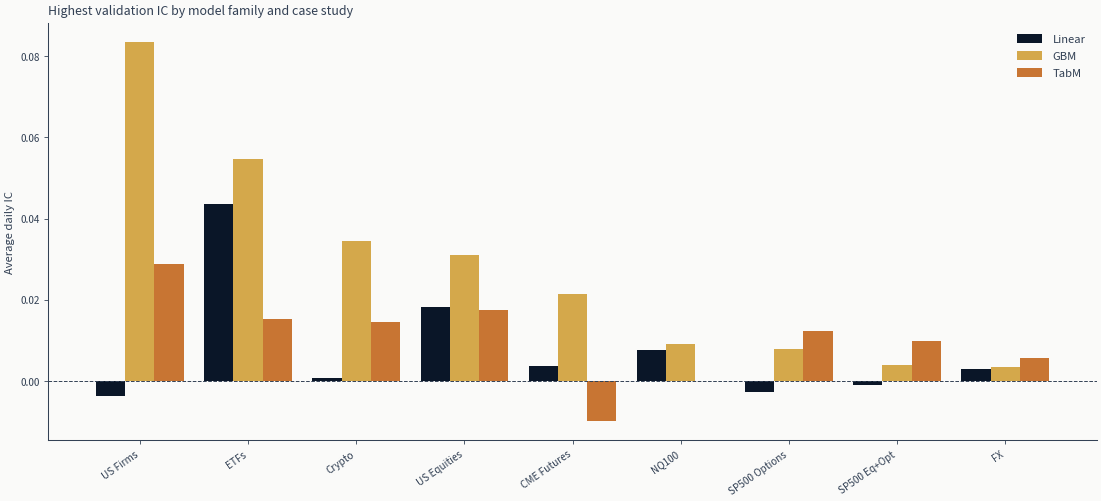

In [65]:
fig, ax = plt.subplots(figsize=(11, 5))
cs_sorted = three_way["short_name"].to_list()
x = np.arange(len(cs_sorted))
width = 0.27
fam_colors = {
    "linear": COLORS["blue"],
    "gbm": COLORS["amber"],
    "tabm": COLORS["copper"],
}
ax.bar(
    x - width,
    three_way["lin_ic"].to_numpy(),
    width=width,
    color=fam_colors["linear"],
    label="Linear",
)
ax.bar(x, three_way["gbm_ic"].to_numpy(), width=width, color=fam_colors["gbm"], label="GBM")
ax.bar(
    x + width, three_way["tabm_ic"].to_numpy(), width=width, color=fam_colors["tabm"], label="TabM"
)
ax.axhline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(cs_sorted, rotation=35, ha="right")
ax.set_ylabel("Average daily IC")
ax.set_title("Highest validation IC by model family and case study")
ax.legend(frameon=False, fontsize=9, loc="best")
show_with_alt(
    fig,
    "Grouped bars of highest validation IC, one group per case study and one bar per "
    "model family, against a line at zero.",
)

The comparison is coverage-explicit in both directions: a family with no result
stays null, and so does a family whose selection was scored over a different number
of days than the GBM selection it would sit beside. Neither is replaced by a result
from another label or a different validation span.

In [66]:
tabm_present = set(tabm_rank1["case_study"].to_list())
tabm_missing = [SHORT_NAMES[cs] for cs in CASE_STUDY_IDS if cs not in tabm_present]
tabm_mismatched = three_way.filter(
    pl.col("tabm_days").is_not_null() & (pl.col("tabm_days") != pl.col("gbm_days"))
)["short_name"].to_list()
tabm_above_gbm = three_way.filter(pl.col("tabm_ic") > pl.col("gbm_ic"))["short_name"].to_list()
display(
    Markdown(
        f"**Computed three-family reading.** TabM has no result for "
        f"{', '.join(tabm_missing) or 'no case study'}, and is masked for unequal coverage "
        f"in {', '.join(tabm_mismatched) or 'no case study'}. Among the rows where both "
        "families were scored over the same number of days, TabM's point estimate exceeds "
        f"GBM for {', '.join(tabm_above_gbm) or 'none'}."
    )
)

**Computed three-family reading.** TabM has no result for NQ100, and is masked for unequal coverage in no case study. Among the rows where both families were scored over the same number of days, TabM's point estimate exceeds GBM for SP500 Options, SP500 Eq+Opt, FX.

## 8. Cross-CS Takeaways

The synthesis below is computed from the selected prediction hashes and their
complete fold panels.

In [67]:
if delta_primary.is_empty():
    delta_takeaway = (
        "- No case study has a selected GBM and a selected Linear configuration scored over the same number of "
        "days, so there is no matched primary-label comparison to summarize.\n"
    )
else:
    top_delta = delta_primary.row(0, named=True)
    delta_takeaway = (
        f"- GBM has the higher average-daily-IC point estimate in {n_positive} of "
        f"{delta_primary.height} matched-coverage primary-label comparisons.\n"
        f"- The largest GBM-minus-linear point estimate is {top_delta['short_name']} "
        f"at {top_delta['delta']:+.4f}; family differences remain descriptive without a "
        "registered daily paired-difference estimator.\n"
    )
display(
    Markdown(
        "**Key takeaways**\n\n"
        + delta_takeaway
        + f"- {len(HORIZON_EXCLUSIONS)} ambiguous optional family-horizon cells are excluded "
        "rather than selected arbitrarily.\n"
        f"- TabM exceeds GBM on {len(tabm_above_gbm)} comparable rows; missing TabM coverage "
        "remains null rather than being substituted.\n\n"
        "**Next**: Ch13 extends the comparison with temporal deep-learning architectures; "
        "Ch14 adds latent-factor models on qualifying panels."
    )
)

**Key takeaways**

- GBM has the higher average-daily-IC point estimate in 9 of 9 matched-coverage primary-label comparisons.
- The largest GBM-minus-linear point estimate is US Firms at +0.0872; family differences remain descriptive without a registered daily paired-difference estimator.
- 2 ambiguous optional family-horizon cells are excluded rather than selected arbitrarily.
- TabM exceeds GBM on 3 comparable rows; missing TabM coverage remains null rather than being substituted.

**Next**: Ch13 extends the comparison with temporal deep-learning architectures; Ch14 adds latent-factor models on qualifying panels.